# 09 — Unified Evaluation Notebook (Multi-Stock WaveNet Lambert GAN)

Evaluation script for the trained multi-stock WaveNet Lambert GAN.

**Architecture:**
- Generator takes dual inputs: `[z_latent (N, 120, 125), macro (N, 120, 46)]`
- Uses half-real/half-noise latent strategy from TimeGAN
- 25 DJ30 tickers × 5 PV features = 125 channels
- PV feature order per ticker: `[close_ret, open_ret, high_ret, low_ret, volume_ret]`

**Protocol:**
- Evaluation in **Lambert-transformed space** (same basis as training)
- Real data: pre-processed NPY arrays from `datasets/output_data_lambert/`
- Synthetic generation: half-real/half-noise + macro conditioning
- Matched sample sizes (real = synthetic count)
- Per-channel metrics use all 125 features; 1D metrics use close returns

**Metrics:**
1. Distribution fidelity — MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence
2. Temporal dynamics — ACF RMSE (returns + squared returns)
3. Geometric distance — Fréchet Distance, DTW
4. Tail behaviour — Mean/Std/Skewness/Kurtosis differences
5. Discriminative score — MLP classifier
6. GRU classifier — Fidelity (accuracy + AUC on 3D sequences)
7. TSTR — Train on Synthetic, Test on Real (usefulness)
8. Visual diagnostics — PCA, t-SNE, sample sequences, distributions
9. Entropy — Shannon, Lempel-Ziv complexity, plug-in entropy
10. QuantGAN metrics — DY (log-density divergence), ACF score (3 transforms), leverage effect
11. Stylized facts — Bouchaud leverage, volatility clustering ACF, tail distribution (Hill estimator)

## 0. Configuration

Change this cell to switch between models.

In [1]:
# ============================================================
# MODEL CONFIGURATION — change this block to evaluate a
# different generator.  Everything downstream is parameterized.
# ============================================================

MODEL_NAME       = 'WaveNet-Lambert-GAN-derived'
MODEL_DIR        = 'output/dj30_v2'          # directory with generator.keras, config.pkl
DATA_DIR         = '../../datasets/output_data_lambert_derived'  # pre-processed NPY data
N_SAMPLES        = 500                    # synthetic sequences to generate

# Training-time ticker list (order matters — must match how the generator was trained).
# Leave as None to use every ticker in the preprocessed dataset (default).
# Only set this to a list if the generator was trained on a strict subset of
# the saved dataset tickers; the realignment logic below will slice + reorder.
TRAIN_TICKERS = None

# Verify artifacts exist
import os
_required_model = ['generator.keras', 'config.pkl']
_required_data  = ['output_data.npy', 'output_macro_data.npy', 'lambert_fit_params.pkl']
for f in _required_model:
    path = os.path.join(MODEL_DIR, f)
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {status}  {path}')
for f in _required_data:
    path = os.path.join(DATA_DIR, f)
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {status}  {path}')


  ✓  output/dj30_v2/generator.keras
  ✓  output/dj30_v2/config.pkl
  ✓  ../../datasets/output_data_lambert_derived/output_data.npy
  ✓  ../../datasets/output_data_lambert_derived/output_macro_data.npy
  ✓  ../../datasets/output_data_lambert_derived/lambert_fit_params.pkl


## 1. Imports & Data Loading

In [2]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure gaussianize module is importable (needed to unpickle lambert_fit_params)
sys.path.insert(0, os.path.join(os.getcwd(), 'models'))
import tensorflow as tf
from tensorflow.keras.models import load_model

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Make metrics importable
import importlib
import metrics.evaluation_metrics as _eval_mod
importlib.reload(_eval_mod)
from metrics.evaluation_metrics import (
    compute_mmd_per_channel,
    compute_acf_per_channel,
    compute_acf_vectors,
    compute_distribution_per_channel,
    compute_tail_metrics_per_channel,
    compute_discriminative_score,
    compute_frechet_distance,
    compute_dtw_distance,
    compute_js_divergence_3d_dynamic_bins,
)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

2026-04-20 21:48:16.759819: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 21:48:16.778612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776721696.811709 1145646 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776721696.819393 1145646 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776721696.837826 1145646 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TensorFlow version: 2.19.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Load saved training config ──
with open(os.path.join(MODEL_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

# Unpack config
SEQ_LEN     = config['seq_len']       # 120
Z_DIM       = config['latent_dim']    # 125
N_FEATURES  = config['feature_dim']   # 125 (25 tickers × 5 PV features)
MACRO_DIM   = config['macro_dim']     # 46
N_TICKERS   = N_FEATURES // 5         # 25

print(f'Config:       seq_len={SEQ_LEN}, feature_dim={N_FEATURES}, '
      f'macro_dim={MACRO_DIM}, latent_dim={Z_DIM}, epochs={config["epochs"]}')

# ── Load pre-processed NPY arrays (real data, already windowed) ──
stock_data = np.load(os.path.join(DATA_DIR, 'output_data.npy')).astype(np.float32)
macro_data = np.load(os.path.join(DATA_DIR, 'output_macro_data.npy')).astype(np.float32)
ticker_list_full = np.load(os.path.join(DATA_DIR, 'ticker_list.npy'))

# Lambert inverse-transform params (per-ticker, per-feature)
with open(os.path.join(DATA_DIR, 'lambert_fit_params.pkl'), 'rb') as f:
    lambert_fit_params = pickle.load(f)

# ── Realign stock_data to the trainer's ticker order ──
# Dataset on disk may include more tickers than the generator was trained on
# (e.g. 28 saved vs 25 trained).  Slice + reorder to match TRAIN_TICKERS.
_pos = {str(t): i for i, t in enumerate(ticker_list_full)}
if TRAIN_TICKERS is None:
    ticker_list = [str(t) for t in ticker_list_full]
else:
    missing = [t for t in TRAIN_TICKERS if t not in _pos]
    if missing:
        raise ValueError(f'TRAIN_TICKERS not found in dataset ticker_list: {missing}')
    ticker_list = list(TRAIN_TICKERS)

_ch_idx = np.concatenate([np.arange(_pos[t] * 5, _pos[t] * 5 + 5) for t in ticker_list])
expected_feat = len(ticker_list) * 5
if expected_feat != N_FEATURES:
    raise ValueError(
        f'TRAIN_TICKERS implies feature_dim={expected_feat} but config says {N_FEATURES}. '
        f'Update TRAIN_TICKERS to match how the generator was trained.'
    )

stock_data = stock_data[:, :, _ch_idx]
print(f'\nRealigned stock_data to {len(ticker_list)} tickers: {stock_data.shape}')
print(f'Macro data shape:  {macro_data.shape}')
print(f'Tickers ({len(ticker_list)}): {ticker_list[:5]} ... {ticker_list[-3:]}')
print(f'Lambert range: [{stock_data.min():.4f}, {stock_data.max():.4f}]')

# ── Register per-channel names for prettier metric printouts ──
try:
    from metrics.evaluation_metrics import set_channel_names, build_multistock_channel_names
    set_channel_names(build_multistock_channel_names(
        ticker_list, ['close_ret', 'open_ret', 'high_ret', 'low_ret', 'volume_ret']))
except Exception as _e:
    print(f'  (channel-name registration skipped: {_e})')

# ── PV feature indices for per-ticker slicing ──
# Feature order per ticker: [close_ret, open_ret, high_ret, low_ret, volume_ret]
PV_NAMES = ['close_ret', 'open_ret', 'high_ret', 'low_ret', 'volume_ret']
CLOSE_IDX = list(range(0, N_FEATURES, 5))  # close return indices: [0, 5, 10, ..., 120]
print(f'Close return feature indices: {CLOSE_IDX[:5]} ... (one per ticker)')


Config:       seq_len=120, feature_dim=140, macro_dim=46, latent_dim=125, epochs=2000

Realigned stock_data to 28 tickers: (5345, 120, 140)
Macro data shape:  (5345, 120, 46)
Tickers (28): ['AAPL', 'AMGN', 'AXP', 'BA', 'CAT'] ... ['WBA', 'WMT', 'GS']
Lambert range: [-2.9206, 3.0196]
Close return feature indices: [0, 5, 10, 15, 20] ... (one per ticker)


## 2. Load Generator & Generate Synthetic Data

In [4]:
# ── Load generator from saved artifacts ──
generator = load_model(os.path.join(MODEL_DIR, 'generator.keras'), safe_mode=False)
print(f'Loaded generator from {MODEL_DIR}/generator.keras')
print(f'  Input shapes:  {[inp.shape for inp in generator.inputs]}')
print(f'  Output shape:  {generator.output_shape}')
print(f'  Parameters:    {generator.count_params():,}')

# ── Generate synthetic sequences (half-real / half-noise + macro) ──
n_eval = min(N_SAMPLES, len(stock_data))
half = SEQ_LEN // 2

# Sample real windows for conditioning context
idx = np.random.choice(len(stock_data), n_eval, replace=n_eval > len(stock_data))
selected_stock = stock_data[idx]
selected_macro = macro_data[idx]

# Build half-real / half-noise latent (TimeGAN strategy)
noise = np.random.randn(n_eval, half, Z_DIM).astype(np.float32)
z = np.concatenate([
    selected_stock[:, :half, :Z_DIM],  # first half: real conditioning
    noise,                               # second half: random noise
], axis=1).astype(np.float32)

raw_synthetic = generator([z, selected_macro], training=False).numpy()
print(f'\nGenerated {n_eval} sequences: {raw_synthetic.shape}')
print(f'  Lambert-space range: [{raw_synthetic.min():.4f}, {raw_synthetic.max():.4f}]')

# ── Final arrays for downstream metrics ──
# Both real and synthetic are in Lambert-transformed space (N, 120, 125)
real_sequences = selected_stock
synthetic_sequences = raw_synthetic

print(f'\nReal sequences:      {real_sequences.shape}')
print(f'Synthetic sequences: {synthetic_sequences.shape}')

# ── Extract close-return features for 1D metrics (QuantGAN, stylized facts) ──
# Average close returns across all 25 tickers → representative 1D series
real_close = real_sequences[:, :, CLOSE_IDX]         # (N, 120, 25)
synth_close = synthetic_sequences[:, :, CLOSE_IDX]   # (N, 120, 25)
real_flat = real_close.mean(axis=2).flatten()         # pool tickers → 1D
synth_flat = synth_close.mean(axis=2).flatten()
print(f'Close-return 1D series: real={len(real_flat)}, synth={len(synth_flat)}')

I0000 00:00:1776721739.503829 1145646 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20833 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:04.0, compute capability: 8.9


Loaded generator from output/dj30_v2/generator.keras
  Input shapes:  [(None, 120, 125), (None, 120, 46)]
  Output shape:  (None, 120, 140)
  Parameters:    9,338,252


I0000 00:00:1776721742.329967 1145646 cuda_dnn.cc:529] Loaded cuDNN version 91002



Generated 500 sequences: (500, 120, 140)
  Lambert-space range: [-5.6375, 3.3021]

Real sequences:      (500, 120, 140)
Synthetic sequences: (500, 120, 140)
Close-return 1D series: real=60000, synth=60000


## 3. Summary Statistics (Sanity Check)

In [5]:
# Quick sanity check before running expensive metrics
# All stats computed in Lambert-transformed space
from scipy.stats import skew, kurtosis

real_all = real_sequences.reshape(-1, N_FEATURES)
synth_all = synthetic_sequences.reshape(-1, N_FEATURES)

stats = pd.DataFrame({
    'Real': [real_all.mean(), real_all.std(), real_all.min(), real_all.max(),
             np.median(real_all)],
    'Synthetic': [synth_all.mean(), synth_all.std(), synth_all.min(), synth_all.max(),
                  np.median(synth_all)],
}, index=['Mean', 'Std', 'Min', 'Max', 'Median'])
stats['Delta'] = stats['Synthetic'] - stats['Real']

print(f"Summary Statistics (Lambert space, all {N_FEATURES} features pooled) — {MODEL_NAME}")
print(stats.to_string(float_format='{:.6f}'.format))

# Per-ticker close-return stats
print(f"\nPer-ticker close-return stats (first 5 tickers):")
for i, ticker in enumerate(ticker_list[:5]):
    col = CLOSE_IDX[i]
    r_vals = real_sequences[:, :, col].flatten()
    s_vals = synthetic_sequences[:, :, col].flatten()
    print(f"  {ticker:>5s}: real μ={r_vals.mean():.4f} σ={r_vals.std():.4f} | "
          f"synth μ={s_vals.mean():.4f} σ={s_vals.std():.4f} | "
          f"Δμ={abs(r_vals.mean()-s_vals.mean()):.4f}")

Summary Statistics (Lambert space, all 140 features pooled) — WaveNet-Lambert-GAN-derived
            Real  Synthetic     Delta
Mean    0.070648   0.069246 -0.001402
Std     0.957962   0.960753  0.002791
Min    -2.920625  -5.637505 -2.716880
Max     3.019567   3.302068  0.282500
Median  0.110501   0.113486  0.002985

Per-ticker close-return stats (first 5 tickers):
   AAPL: real μ=0.0082 σ=0.9651 | synth μ=-0.0210 σ=0.9655 | Δμ=0.0291
   AMGN: real μ=-0.0078 σ=0.9815 | synth μ=-0.0041 σ=0.9841 | Δμ=0.0038
    AXP: real μ=-0.0076 σ=1.0054 | synth μ=-0.0280 σ=1.0124 | Δμ=0.0204
     BA: real μ=0.0013 σ=1.0106 | synth μ=0.0165 σ=1.0061 | Δμ=0.0152
    CAT: real μ=-0.0059 σ=0.9982 | synth μ=0.0077 σ=0.9976 | Δμ=0.0136


## 4A. Distribution Fidelity

MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence.

In [6]:
# ============================================
# MMD (multi-scale RBF, per-channel)
# ============================================
mmd_results = compute_mmd_per_channel(real_sequences, synthetic_sequences,
                                       num_samples=n_eval)
print(f"MMD (multi-scale RBF): {mmd_results['mean']:.6f}")
for ch, val in mmd_results.items():
    if ch != 'mean':
        print(f"  {ch}: {val:.6f}")

# ============================================
# Wasserstein-1 & KS test
# ============================================
dist_results = compute_distribution_per_channel(real_sequences, synthetic_sequences)
print(f"\nWasserstein-1 (mean): {dist_results['mean_wasserstein']:.6f}")
print(f"KS statistic (mean): {dist_results['mean_ks']:.4f}")
for ch in dist_results['wasserstein']:
    print(f"  {ch}: W={dist_results['wasserstein'][ch]:.6f}, "
          f"KS={dist_results['ks_statistic'][ch]:.4f}, "
          f"p={dist_results['ks_pvalue'][ch]:.4f}")

# ============================================
# JS Divergence
# ============================================
js_similarity = compute_js_divergence_3d_dynamic_bins(real_sequences, synthetic_sequences)
js_divergence = (100 - js_similarity) / 100  # Convert back to [0,1] divergence
print(f"\nJS Divergence: {js_divergence:.6f}")
print(f"JS Similarity: {js_similarity:.2f}%")

MMD (multi-scale RBF): 0.004031
  AAPL_close_ret: 0.003992
  AAPL_open_ret: 0.003878
  AAPL_high_ret: 0.003897
  AAPL_low_ret: 0.003863
  AAPL_volume_ret: 0.010044
  AMGN_close_ret: 0.003912
  AMGN_open_ret: 0.003862
  AMGN_high_ret: 0.004007
  AMGN_low_ret: 0.003884
  AMGN_volume_ret: 0.004224
  AXP_close_ret: 0.003915
  AXP_open_ret: 0.003839
  AXP_high_ret: 0.003919
  AXP_low_ret: 0.003824
  AXP_volume_ret: 0.003995
  BA_close_ret: 0.003874
  BA_open_ret: 0.003800
  BA_high_ret: 0.003864
  BA_low_ret: 0.003845
  BA_volume_ret: 0.004395
  CAT_close_ret: 0.003814
  CAT_open_ret: 0.003835
  CAT_high_ret: 0.003799
  CAT_low_ret: 0.003819
  CAT_volume_ret: 0.004676
  CSCO_close_ret: 0.003867
  CSCO_open_ret: 0.003891
  CSCO_high_ret: 0.003851
  CSCO_low_ret: 0.003818
  CSCO_volume_ret: 0.004317
  CVX_close_ret: 0.003872
  CVX_open_ret: 0.003858
  CVX_high_ret: 0.003841
  CVX_low_ret: 0.003880
  CVX_volume_ret: 0.004195
  DIS_close_ret: 0.003877
  DIS_open_ret: 0.003849
  DIS_high_ret: 0.

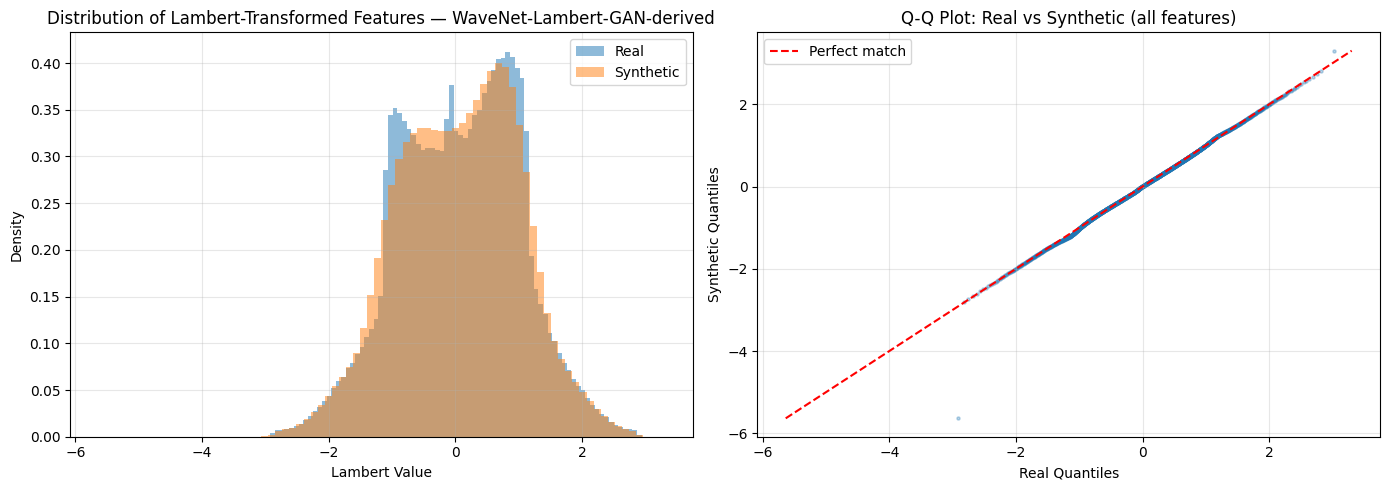

In [7]:
# Distribution plots — histogram + QQ (pooling all 125 features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Lambert-space values (all features pooled)
axes[0].hist(real_all.flatten(), bins=80, alpha=0.5, density=True, label='Real')
axes[0].hist(synth_all.flatten(), bins=80, alpha=0.5, density=True, label='Synthetic')
axes[0].set_title(f'Distribution of Lambert-Transformed Features — {MODEL_NAME}')
axes[0].set_xlabel('Lambert Value')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# QQ plot (pooled)
real_sorted = np.sort(real_all.flatten())
synth_sorted = np.sort(synth_all.flatten())
n_qq = min(2000, len(real_sorted), len(synth_sorted))
axes[1].scatter(
    real_sorted[np.linspace(0, len(real_sorted)-1, n_qq, dtype=int)],
    synth_sorted[np.linspace(0, len(synth_sorted)-1, n_qq, dtype=int)],
    alpha=0.3, s=5
)
lims = [min(real_sorted.min(), synth_sorted.min()),
        max(real_sorted.max(), synth_sorted.max())]
axes[1].plot(lims, lims, 'r--', label='Perfect match')
axes[1].set_title('Q-Q Plot: Real vs Synthetic (all features)')
axes[1].set_xlabel('Real Quantiles')
axes[1].set_ylabel('Synthetic Quantiles')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4B. Temporal Dynamics

Autocorrelation RMSE for returns and squared returns (volatility clustering).

ACF RMSE (returns, ch=AAPL_close_ret):         0.017268
ACF RMSE (squared returns, ch=AAPL_close_ret): 0.065885


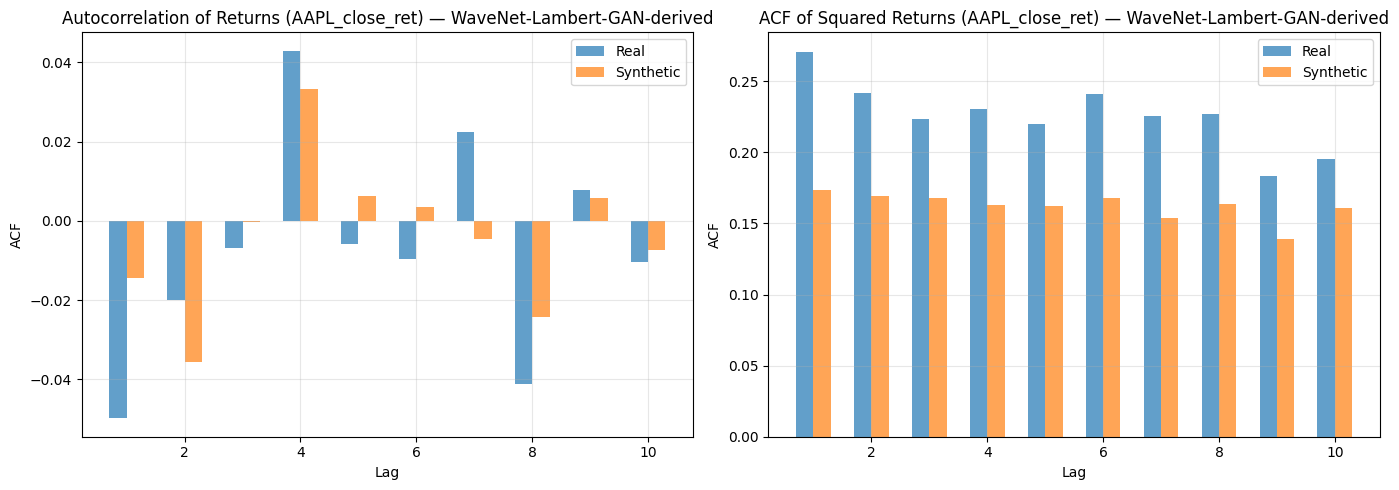

In [8]:
# ACF comparison — uses compute_acf_vectors for plotting
acf = compute_acf_vectors(real_sequences, synthetic_sequences, max_lag=10)
lags = acf['lags']

# Also get scalar RMSE from compute_acf_per_channel (for summary table later)
acf_rmse_results = compute_acf_per_channel(real_sequences, synthetic_sequences, max_lag=10)

# Get the first channel (of 125) for plotting
ch_name = list(acf['returns'].keys())[0]
ret = acf['returns'][ch_name]
sq = acf['squared'][ch_name]

print(f"ACF RMSE (returns, ch={ch_name}):         {ret['rmse']:.6f}")
print(f"ACF RMSE (squared returns, ch={ch_name}): {sq['rmse']:.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lags - 0.15, ret['real'], width=0.3, label='Real', alpha=0.7)
axes[0].bar(lags + 0.15, ret['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
axes[0].set_title(f'Autocorrelation of Returns ({ch_name}) — {MODEL_NAME}')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(lags - 0.15, sq['real'], width=0.3, label='Real', alpha=0.7)
axes[1].bar(lags + 0.15, sq['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
axes[1].set_title(f'ACF of Squared Returns ({ch_name}) — {MODEL_NAME}')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4C. Geometric / Embedding Distance

Fréchet Distance (joint) and DTW.

In [9]:
# ============================================
# Fréchet Distance (joint, per-channel)
# ============================================
fd_results = compute_frechet_distance(real_sequences, synthetic_sequences, per_channel=True)
print(f"Fréchet Distance (joint):       {fd_results['overall_fd']:.6f}")
print(f"Fréchet Distance (avg channel): {fd_results['average_channel_fd']:.6f}")
for ch, val in fd_results['channel_fd'].items():
    print(f"  {ch}: {val:.6f}")

# ============================================
# DTW Distance (subsampled for speed)
# ============================================
n_dtw = min(50, n_eval)  # DTW is O(n²) per pair — subsample
dtw_real = real_sequences[:n_dtw]
dtw_synth = synthetic_sequences[:n_dtw]
dtw_score = compute_dtw_distance(dtw_real, dtw_synth)
print(f"\nDTW Distance (mean, n={n_dtw}): {dtw_score:.6f}")

Fréchet Distance (joint):       4.799627
Fréchet Distance (avg channel): 0.001093
  Channel_0: 0.000850
  Channel_1: 0.000462
  Channel_2: 0.002664
  Channel_3: 0.000318
  Channel_4: 0.000920
  Channel_5: 0.000021
  Channel_6: 0.000181
  Channel_7: 0.002799
  Channel_8: 0.001475
  Channel_9: 0.001161
  Channel_10: 0.000466
  Channel_11: 0.000040
  Channel_12: 0.003751
  Channel_13: 0.000921
  Channel_14: 0.000367
  Channel_15: 0.000251
  Channel_16: 0.000022
  Channel_17: 0.001662
  Channel_18: 0.002030
  Channel_19: 0.000508
  Channel_20: 0.000186
  Channel_21: 0.000636
  Channel_22: 0.003044
  Channel_23: 0.001183
  Channel_24: 0.001197
  Channel_25: 0.000300
  Channel_26: 0.001185
  Channel_27: 0.002647
  Channel_28: 0.001210
  Channel_29: 0.001627
  Channel_30: 0.000062
  Channel_31: 0.000612
  Channel_32: 0.000759
  Channel_33: 0.000471
  Channel_34: 0.000019
  Channel_35: 0.000138
  Channel_36: 0.000269
  Channel_37: 0.001040
  Channel_38: 0.000800
  Channel_39: 0.000864
  Channe

## 4D. Tail Behaviour & Higher-Order Statistics

Mean, std, skewness, and kurtosis differences — critical for financial risk modelling.

Tail metrics (140 channels):
  AAPL_close_ret: mean Δ=0.029144, std ratio=1.0004, skew Δ=0.0429, kurt Δ=0.0589
  AAPL_high_ret: mean Δ=0.051524, std ratio=1.0031, skew Δ=0.5185, kurt Δ=0.1778
  AAPL_low_ret: mean Δ=0.016753, std ratio=1.0063, skew Δ=0.5407, kurt Δ=0.1759
  AAPL_open_ret: mean Δ=0.020406, std ratio=1.0068, skew Δ=0.0128, kurt Δ=0.0732
  AAPL_volume_ret: mean Δ=0.029747, std ratio=1.0074, skew Δ=0.0090, kurt Δ=0.3384
  ... (135 more channels)


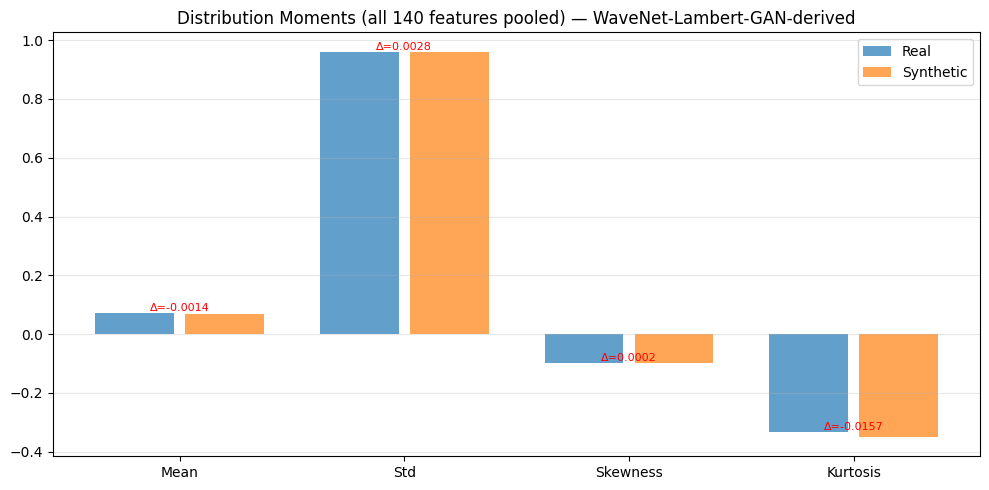

In [10]:
from scipy.stats import skew, kurtosis

tail_results = compute_tail_metrics_per_channel(real_sequences, synthetic_sequences)

# Show first few channels
ch_names = sorted(tail_results['mean_diff'].keys())
print(f"Tail metrics ({len(ch_names)} channels):")
for ch in ch_names[:5]:
    print(f"  {ch}: mean Δ={tail_results['mean_diff'][ch]:.6f}, "
          f"std ratio={tail_results['std_ratio'][ch]:.4f}, "
          f"skew Δ={tail_results['skew_diff'][ch]:.4f}, "
          f"kurt Δ={tail_results['kurtosis_diff'][ch]:.4f}")
if len(ch_names) > 5:
    print(f"  ... ({len(ch_names) - 5} more channels)")

# Bar chart — real vs synthetic moment values (pooled across all features)
real_pooled = real_all.flatten()
synth_pooled = synth_all.flatten()
moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']
real_moments = [np.mean(real_pooled), np.std(real_pooled),
                skew(real_pooled), kurtosis(real_pooled)]
synth_moments = [np.mean(synth_pooled), np.std(synth_pooled),
                 skew(synth_pooled), kurtosis(synth_pooled)]

x = np.arange(len(moment_names))
fig, ax = plt.subplots(figsize=(10, 5))
bars_r = ax.bar(x - 0.2, real_moments, 0.35, label='Real', alpha=0.7)
bars_s = ax.bar(x + 0.2, synth_moments, 0.35, label='Synthetic', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(moment_names)
ax.set_title(f'Distribution Moments (all {N_FEATURES} features pooled) — {MODEL_NAME}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (r, s) in enumerate(zip(real_moments, synth_moments)):
    delta = s - r
    ax.annotate(f'Δ={delta:.4f}', xy=(i, max(r, s)),
                ha='center', va='bottom', fontsize=8, color='red')

plt.tight_layout()
plt.show()

## 4E. Discriminative Score

MLP classifier trained to distinguish real from synthetic.  
Score = |accuracy − 0.5|. Lower = better (indistinguishable).

In [11]:
disc_results = compute_discriminative_score(real_sequences, synthetic_sequences)
print(f"Discriminative Accuracy: {disc_results['accuracy']:.4f}")
print(f"Discriminative Score:    {disc_results['score']:.4f}  (closer to 0 = better)")

Discriminative Accuracy: 0.4450
Discriminative Score:    0.0550  (closer to 0 = better)


## 4F. GRU Classifier — Fidelity Assessment

A GRU-based time series classifier trained to distinguish real from synthetic
sequences on the **full 3D data** (preserving temporal structure).  
Adapted from the original TimeGAN evaluation (Yoon et al. 2019).

GRU Classifier — Test Accuracy: 1.0000, AUC: 1.0000, Score: 0.5000


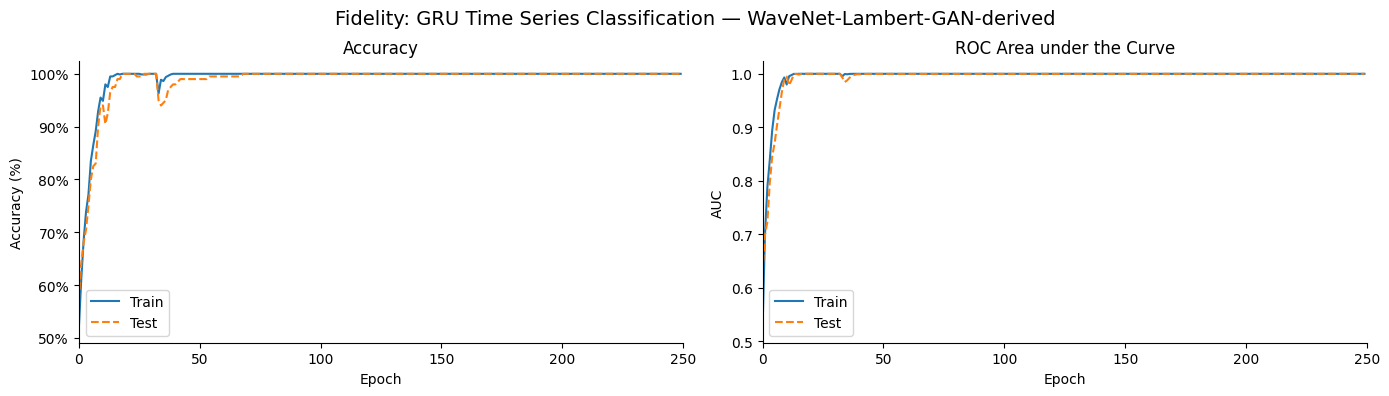

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.metrics import AUC
from matplotlib.ticker import FuncFormatter

# --- Prepare labelled dataset (3D) ---
n_series = n_eval
idx_split = np.arange(n_series)
n_train = int(0.8 * n_series)
train_idx, test_idx = idx_split[:n_train], idx_split[n_train:]

train_data = np.vstack((real_sequences[train_idx], synthetic_sequences[train_idx]))
test_data  = np.vstack((real_sequences[test_idx],  synthetic_sequences[test_idx]))

n_train_cls, n_test_cls = len(train_idx), len(test_idx)
train_labels = np.concatenate([np.ones(n_train_cls), np.zeros(n_train_cls)])
test_labels  = np.concatenate([np.ones(n_test_cls),  np.zeros(n_test_cls)])

# --- Build GRU classifier (125 features) ---
gru_classifier = Sequential([
    Input(shape=(SEQ_LEN, N_FEATURES)),
    GRU(64, name='GRU'),
    Dense(1, activation='sigmoid', name='OUT')
], name='TS_Classifier')

gru_classifier.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=[AUC(name='AUC'), 'accuracy'])

gru_result = gru_classifier.fit(
    x=train_data, y=train_labels,
    validation_data=(test_data, test_labels),
    epochs=250, batch_size=128, verbose=0
)

gru_test_loss, gru_test_auc, gru_test_acc = gru_classifier.evaluate(
    test_data, test_labels, verbose=0
)
gru_disc_score = abs(0.5 - gru_test_acc)

print(f"GRU Classifier — Test Accuracy: {gru_test_acc:.4f}, "
      f"AUC: {gru_test_auc:.4f}, Score: {gru_disc_score:.4f}")

# --- Plot training curves ---
history = pd.DataFrame(gru_result.history)
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))

history[['accuracy', 'val_accuracy']].rename(
    columns={'accuracy': 'Train', 'val_accuracy': 'Test'}
).plot(ax=axes[0], title='Accuracy', style=['-', '--'], xlim=(0, 250))
axes[0].set_xlabel('Epoch')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Accuracy (%)')

history[['AUC', 'val_AUC']].rename(
    columns={'AUC': 'Train', 'val_AUC': 'Test'}
).plot(ax=axes[1], title='ROC Area under the Curve',
       style=['-', '--'], xlim=(0, 250))
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')

sns.despine()
fig.suptitle(f'Fidelity: GRU Time Series Classification — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FuncFormatter

# --- Prepare labelled dataset (3D), stratified split ---
n_series = n_eval
train_idx, test_idx = train_test_split(
    np.arange(n_series), test_size=0.2, random_state=42
)

train_data = np.vstack((real_sequences[train_idx], synthetic_sequences[train_idx]))
test_data  = np.vstack((real_sequences[test_idx],  synthetic_sequences[test_idx]))

train_labels = np.concatenate([np.ones(len(train_idx)), np.zeros(len(train_idx))])
test_labels  = np.concatenate([np.ones(len(test_idx)),  np.zeros(len(test_idx))])

# --- Build GRU classifier (logits output, no sigmoid) ---
# Dense(1) with no activation emits raw logits; BinaryCrossentropy(from_logits=True)
# uses sigmoid_cross_entropy_with_logits internally, which is numerically stable
# for |logit| > 10 where a sigmoid+BCE combo saturates to 0/1 and the gradient
# (and the reported accuracy) become meaningless.
gru_classifier = Sequential([
    Input(shape=(SEQ_LEN, N_FEATURES)),
    GRU(64, name='GRU'),
    Dense(1, name='OUT')                                  # logits, no activation
], name='TS_Classifier')

gru_classifier.compile(
    loss=BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=[AUC(from_logits=True, name='AUC'),
             BinaryAccuracy(threshold=0.0, name='accuracy')]  # threshold on logits
)

gru_result = gru_classifier.fit(
    x=train_data, y=train_labels,
    validation_data=(test_data, test_labels),
    epochs=250, batch_size=128, verbose=0,
)

gru_test_loss, gru_test_auc, gru_test_acc = gru_classifier.evaluate(
    test_data, test_labels, verbose=0
)
gru_disc_score = abs(0.5 - gru_test_acc)

print(f"GRU Classifier — Test Accuracy: {gru_test_acc:.4f}, "
      f"AUC: {gru_test_auc:.4f}, Score: {gru_disc_score:.4f}")

# --- Saturation diagnostic: inspect raw logits ---
logits = gru_classifier.predict(test_data[:32], verbose=0).ravel()
extreme = int(np.sum(np.abs(logits) > 20))
print(f"Logit range: [{logits.min():.3f}, {logits.max():.3f}]   "
      f"|logit|>20 count: {extreme}/32")

# --- Plot training curves ---
history = pd.DataFrame(gru_result.history)
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))

history[['accuracy', 'val_accuracy']].rename(
    columns={'accuracy': 'Train', 'val_accuracy': 'Test'}
).plot(ax=axes[0], title='Accuracy', style=['-', '--'], xlim=(0, 250))
axes[0].set_xlabel('Epoch')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Accuracy (%)')

history[['AUC', 'val_AUC']].rename(
    columns={'AUC': 'Train', 'val_AUC': 'Test'}
).plot(ax=axes[1], title='ROC Area under the Curve',
       style=['-', '--'], xlim=(0, 250))
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')

sns.despine()
fig.suptitle(f'Fidelity: GRU Time Series Classification — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

## 4G. TSTR — Train on Synthetic, Test on Real (Usefulness)

Train a GRU regression model to predict the next time step.  
Compare: model trained on **synthetic** vs model trained on **real** data,  
both tested on held-out real data.  If the synthetic-trained model performs  
comparably, the synthetic data is *useful* for downstream ML tasks.

TSTR MAE (Train Synthetic, Test Real): 0.684769
TRTR MAE (Train Real, Test Real):      0.672715
TSTR / TRTR ratio:                     1.0179  (closer to 1.0 = better)


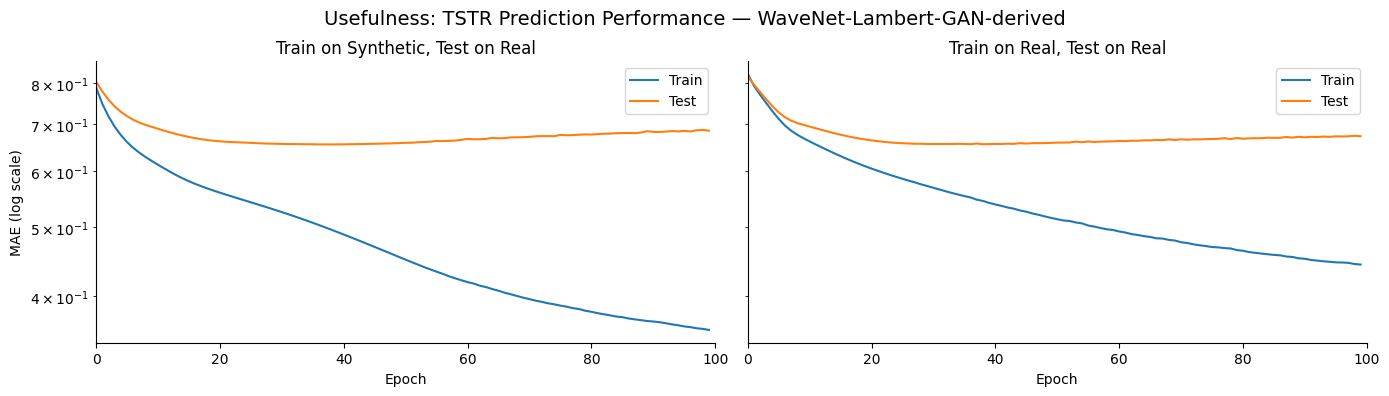

In [13]:
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam

# --- Split sequences: input = t[0:-1], label = t[-1] ---
real_train_X = real_sequences[train_idx, :-1, :]   # (n_train, SEQ_LEN-1, 125)
real_train_y = real_sequences[train_idx, -1, :]     # (n_train, 125)
real_test_X  = real_sequences[test_idx, :-1, :]
real_test_y  = real_sequences[test_idx, -1, :]

synth_train_X = synthetic_sequences[:, :-1, :]      # use all synthetic for training
synth_train_y = synthetic_sequences[:, -1, :]

def build_predictor():
    model = Sequential([
        Input(shape=(SEQ_LEN - 1, N_FEATURES)),
        GRU(64),
        Dense(N_FEATURES)
    ])
    model.compile(optimizer=Adam(), loss=MeanAbsoluteError(name='MAE'))
    return model

# --- Train on Synthetic, Test on Real ---
tstr_model = build_predictor()
tstr_result = tstr_model.fit(
    x=synth_train_X, y=synth_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
tstr_mae = tstr_model.evaluate(real_test_X, real_test_y, verbose=0)

# --- Train on Real, Test on Real (baseline) ---
trtr_model = build_predictor()
trtr_result = trtr_model.fit(
    x=real_train_X, y=real_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
trtr_mae = trtr_model.evaluate(real_test_X, real_test_y, verbose=0)

print(f"TSTR MAE (Train Synthetic, Test Real): {tstr_mae:.6f}")
print(f"TRTR MAE (Train Real, Test Real):      {trtr_mae:.6f}")
print(f"TSTR / TRTR ratio:                     {tstr_mae / trtr_mae:.4f}  (closer to 1.0 = better)")

# --- Plot training curves ---
tstr_hist = pd.DataFrame(tstr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})
trtr_hist = pd.DataFrame(trtr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})

fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)
tstr_hist.plot(ax=axes[0], title='Train on Synthetic, Test on Real',
               logy=True, xlim=(0, 100))
trtr_hist.plot(ax=axes[1], title='Train on Real, Test on Real',
               logy=True, xlim=(0, 100))
for i in [0, 1]:
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MAE (log scale)')

sns.despine()
fig.suptitle(f'Usefulness: TSTR Prediction Performance — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

## 5. Visual Diagnostics

PCA, t-SNE, and sample sequence comparison.

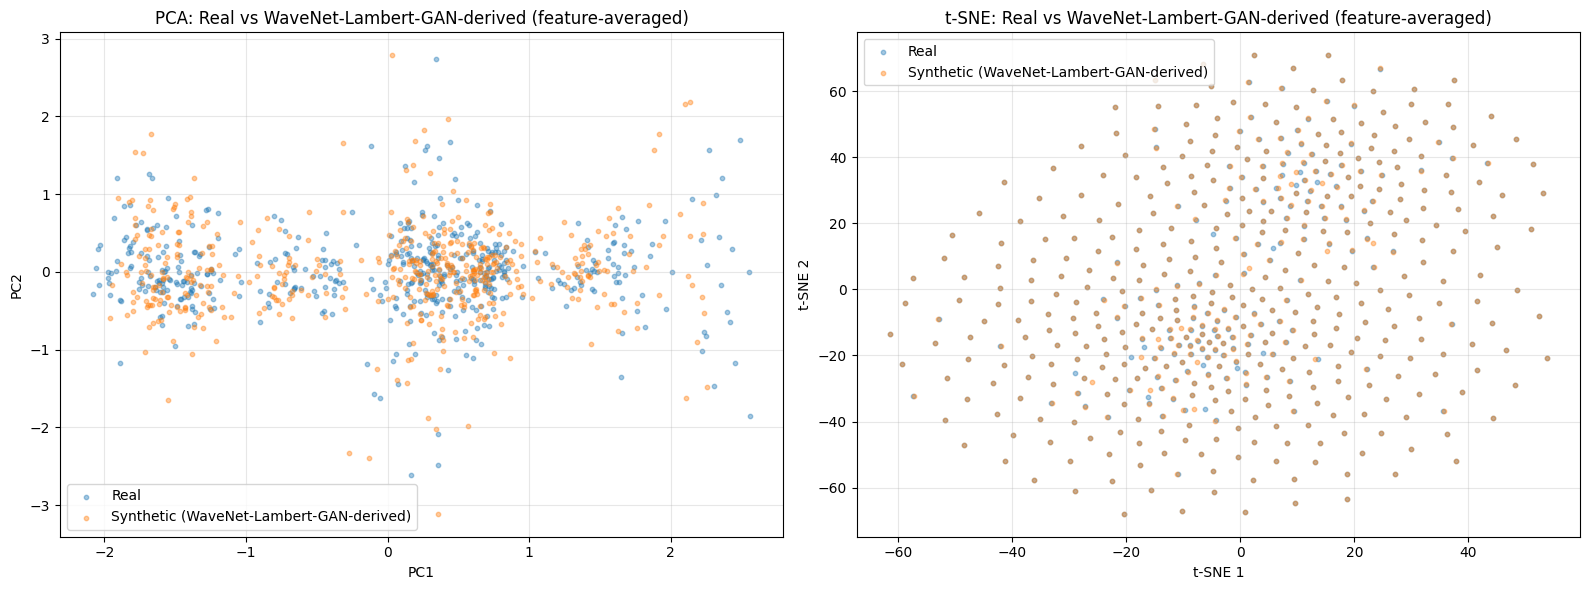

In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# For PCA/t-SNE: average across features → (N, SEQ_LEN)
real_avg = np.mean(real_sequences, axis=2)       # (N, 120)
synth_avg = np.mean(synthetic_sequences, axis=2) # (N, 120)

combined = np.vstack([real_avg, synth_avg])
labels = np.array([0] * n_eval + [1] * n_eval)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined)
axes[0].scatter(pca_result[labels==0, 0], pca_result[labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[0].scatter(pca_result[labels==1, 0], pca_result[labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[0].set_title(f'PCA: Real vs {MODEL_NAME} (feature-averaged)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE (subsample for speed)
n_tsne = min(500, n_eval)
idx_real = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval)
idx_synth = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval) + n_eval
idx_all = np.concatenate([idx_real, idx_synth])

tsne = TSNE(n_components=2, perplexity=min(30, n_tsne - 1), random_state=42)
tsne_result = tsne.fit_transform(combined[idx_all])
tsne_labels = labels[idx_all]

axes[1].scatter(tsne_result[tsne_labels==0, 0], tsne_result[tsne_labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[1].scatter(tsne_result[tsne_labels==1, 0], tsne_result[tsne_labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[1].set_title(f't-SNE: Real vs {MODEL_NAME} (feature-averaged)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

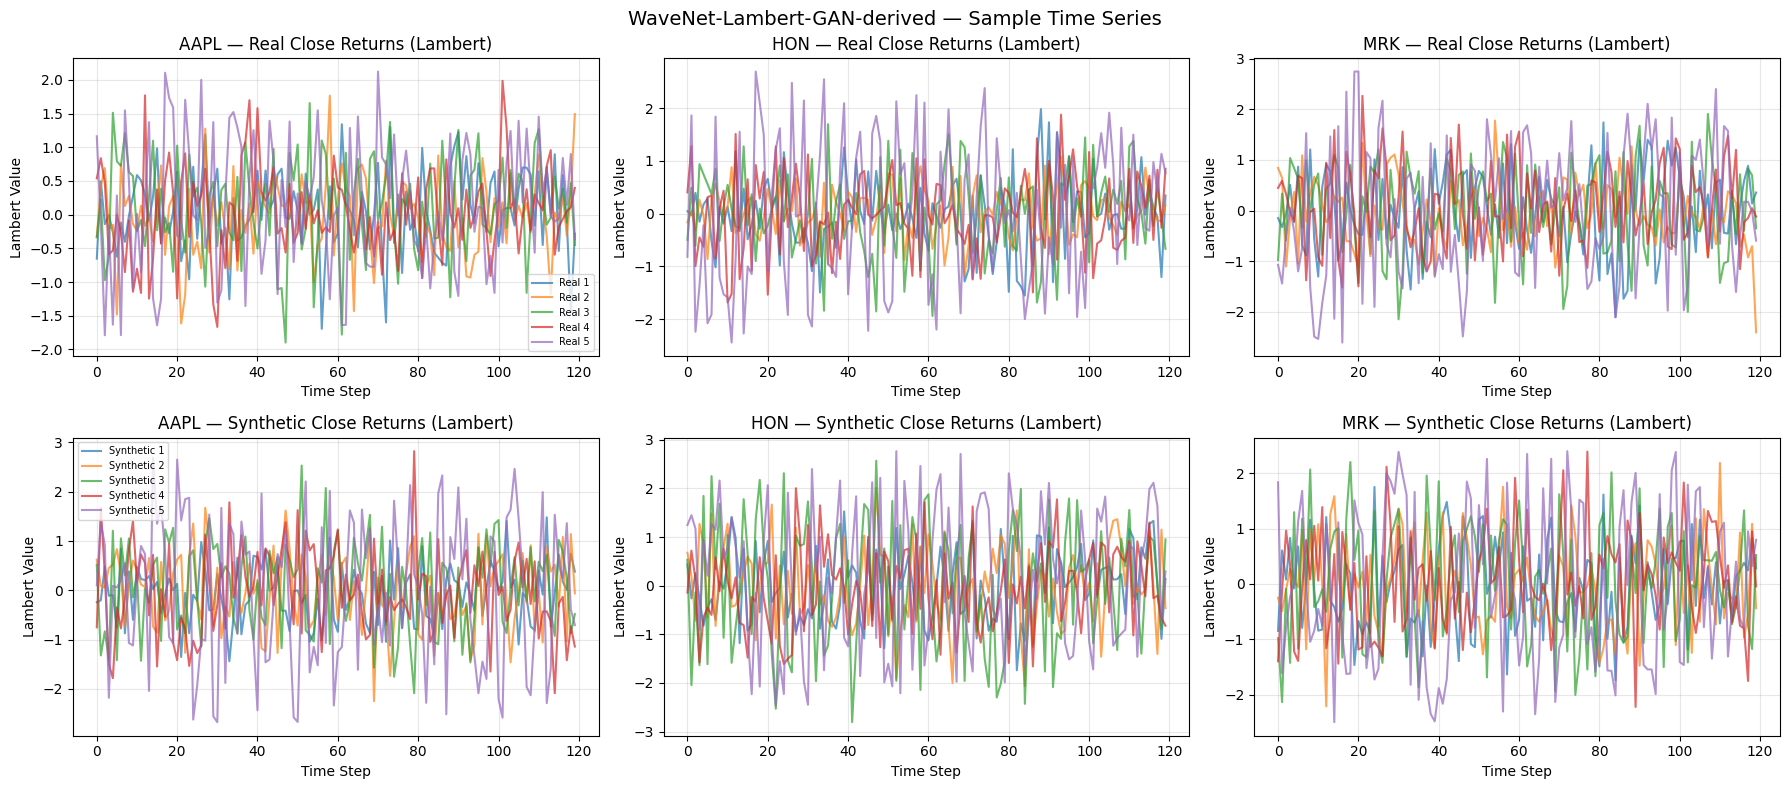

In [15]:
# Sample sequences — 5 real vs 5 synthetic for representative tickers
# Show close returns in Lambert space for 3 tickers
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

sample_tickers = [0, 9, 17]  # AAPL, HON, MSFT
plot_idx = np.linspace(0, n_eval - 1, 5, dtype=int)

for col, t_idx in enumerate(sample_tickers):
    col_idx = CLOSE_IDX[t_idx]
    ticker_name = ticker_list[t_idx]

    for i in range(5):
        axes[0, col].plot(real_sequences[plot_idx[i], :, col_idx],
                          alpha=0.7, label=f'Real {i+1}')
    axes[0, col].set_title(f'{ticker_name} — Real Close Returns (Lambert)')
    axes[0, col].set_xlabel('Time Step')
    axes[0, col].set_ylabel('Lambert Value')
    if col == 0:
        axes[0, col].legend(fontsize=7)
    axes[0, col].grid(True, alpha=0.3)

    for i in range(5):
        axes[1, col].plot(synthetic_sequences[i, :, col_idx],
                          alpha=0.7, label=f'Synthetic {i+1}')
    axes[1, col].set_title(f'{ticker_name} — Synthetic Close Returns (Lambert)')
    axes[1, col].set_xlabel('Time Step')
    axes[1, col].set_ylabel('Lambert Value')
    if col == 0:
        axes[1, col].legend(fontsize=7)
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — Sample Time Series', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## 5b. Entropy Analysis

Compare the information-theoretic structure of real vs synthetic sequences using three complementary entropy measures:

- **Shannon Entropy** — measures marginal randomness of the discretised series
- **Lempel-Ziv Complexity** — captures pattern/substring diversity (mode-collapse detector)
- **Plug-in Entropy (word=2)** — captures transition / bigram structure

Values are computed after quantile-binning each series into 5 equal-frequency bins. A good generator should closely match the real data's entropy on all three measures.

In [16]:
from metrics.evaluation_metrics import compute_entropy_metrics

entropy_results = compute_entropy_metrics(real_sequences, synthetic_sequences, n_bins=5)

ch = list(entropy_results['shannon_real'].keys())[0]

print("=" * 65)
print(f"  {MODEL_NAME} — Entropy Analysis")
print("=" * 65)
print(f"  {'Metric':<35} {'Real':>10} {'Synth':>10} {'|Δ|':>10}")
print("-" * 65)
print(f"  {'Shannon Entropy (bits)':<35} "
      f"{entropy_results['shannon_real'][ch]:>10.4f} "
      f"{entropy_results['shannon_synth'][ch]:>10.4f} "
      f"{entropy_results['shannon_diff'][ch]:>10.4f}")
print(f"  {'Lempel-Ziv Complexity':<35} "
      f"{entropy_results['lz_real'][ch]:>10.4f} "
      f"{entropy_results['lz_synth'][ch]:>10.4f} "
      f"{entropy_results['lz_diff'][ch]:>10.4f}")
print(f"  {'Plug-in Entropy (w=2, bits)':<35} "
      f"{entropy_results['plugin2_real'][ch]:>10.4f} "
      f"{entropy_results['plugin2_synth'][ch]:>10.4f} "
      f"{entropy_results['plugin2_diff'][ch]:>10.4f}")
print("=" * 65)

# Interpretation
lz_ratio = entropy_results['lz_synth'][ch] / max(entropy_results['lz_real'][ch], 1e-8)
if lz_ratio < 0.85:
    print("\n  ⚠  LZ complexity is significantly LOWER than real data → possible mode collapse")
elif lz_ratio > 1.15:
    print("\n  ⚠  LZ complexity is significantly HIGHER than real data → over-random / noisy")
else:
    print("\n  ✓  LZ complexity is within 15% of real data → good pattern diversity")

sh_diff = entropy_results['shannon_diff'][ch]
if sh_diff < 0.05:
    print("  ✓  Shannon entropy match is excellent (Δ < 0.05 bits)")
elif sh_diff < 0.15:
    print("  ~  Shannon entropy match is acceptable (Δ < 0.15 bits)")
else:
    print(f"  ⚠  Shannon entropy gap is large (Δ = {sh_diff:.4f} bits)")

  WaveNet-Lambert-GAN-derived — Entropy Analysis
  Metric                                    Real      Synth        |Δ|
-----------------------------------------------------------------
  Shannon Entropy (bits)                  2.3219     2.3200     0.0019
  Lempel-Ziv Complexity                   0.1644     0.1744     0.0101
  Plug-in Entropy (w=2, bits)             4.6194     4.6308     0.0115

  ✓  LZ complexity is within 15% of real data → good pattern diversity
  ✓  Shannon entropy match is excellent (Δ < 0.05 bits)


## 5c. QuantGAN-style Metrics (Wiese et al., 2020)

Three metrics from the original Quant GANs paper (arXiv:1907.06673):

- **DY metric** (Drǎgulescu & Yakovenko, 2002) — log-density divergence at multiple time lags (1, 5, 20 days). Measures distributional fidelity across different return horizons.
- **ACF score** — L2 norm of ACF difference for three transforms: $f(x) = x$ (serial), $f(x) = x^2$ (squared/vol clustering), $f(x) = |x|$ (absolute). Captures temporal dependence structure.
- **Leverage effect score** — Compares $\text{Corr}(r_{t+\tau}^2, r_t)$ curves. Captures the asymmetric negative correlation between volatility and returns (a key stylized fact).

  WaveNet-Lambert-GAN-derived — QuantGAN Metrics (Wiese et al., 2020)
  (Using averaged close returns across 28 tickers)

  DY Metric (log-density divergence, lower = better):
    DY(1)            6.0440
    DY(5)            7.1610
    DY(20)           6.1597
    DY(100)          6.9034



  ACF Score — Lambert close returns (windowed, K=119 lags):
    Metric                         L2 (QuantGAN) MSE (MiT-WGAN)
    --------------------------------------------------------
    ACF(x)  — serial                     0.0590       2.92e-05
    ACF(x²) — squared                    0.0667       3.73e-05
    ACF(|x|) — absolute                  0.0739       4.59e-05

  ACF Score — Contiguous close returns (contiguous, K=250 lags, N=60000 pts):
    Metric                         L2 (QuantGAN) MSE (MiT-WGAN)
    --------------------------------------------------------
    ACF(x)  — serial                     0.1003       4.02e-05
    ACF(x²) — squared                    0.5476       1.20e-03
    ACF(|x|) — absolute                  0.3993       6.38e-04

  Leverage Effect Score (L2, lower = better):
    Score                              0.1471


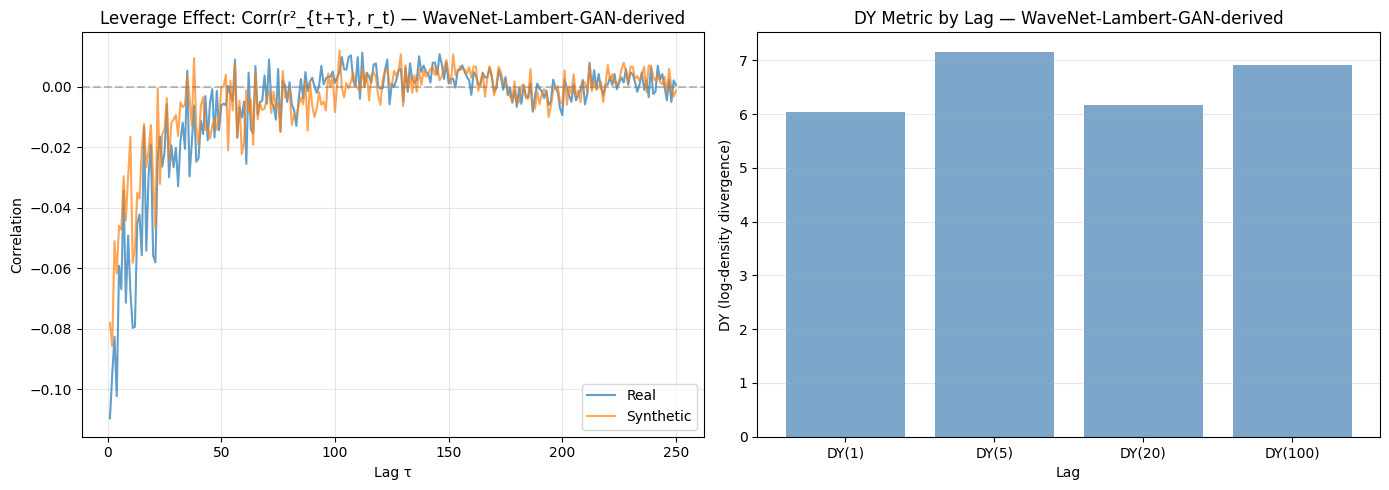

In [17]:
from metrics.evaluation_metrics import (
    compute_dy_metric, compute_quantgan_acf_score, compute_leverage_effect_score
)

# QuantGAN metrics use 1D series — we use averaged close returns across tickers
# real_flat / synth_flat were defined in Cell 8 as mean of close returns

# --- DY Metric (multi-lag distributional divergence) ---
max_feasible_lag = min(len(real_flat), len(synth_flat)) // 2
dy_lags = tuple(l for l in (1, 5, 20, 100) if l < max_feasible_lag)
dy_results = compute_dy_metric(real_flat, synth_flat, lags=dy_lags)

print("=" * 65)
print(f"  {MODEL_NAME} — QuantGAN Metrics (Wiese et al., 2020)")
print(f"  (Using averaged close returns across {N_TICKERS} tickers)")
print("=" * 65)
print(f"\n  DY Metric (log-density divergence, lower = better):")
for key, val in dy_results.items():
    print(f"    {key:<12} {val:>10.4f}")

# --- ACF Score (3-transform) ---
# Windowed close returns (N, 120, 25)
qacf = compute_quantgan_acf_score(real_close.mean(axis=2), synth_close.mean(axis=2), max_lag=250)

print(f"\n  ACF Score — Lambert close returns ({qacf['mode']}, "
      f"K={qacf['max_lag']} lags):")
print(f"    {'Metric':<30} {'L2 (QuantGAN)':>12} {'MSE (MiT-WGAN)':>14}")
print(f"    {'-'*56}")
print(f"    {'ACF(x)  — serial':<30} {qacf['acf_identity']:>12.4f} {qacf['acf_identity_mse']:>14.2e}")
print(f"    {'ACF(x²) — squared':<30} {qacf['acf_squared']:>12.4f} {qacf['acf_squared_mse']:>14.2e}")
print(f"    {'ACF(|x|) — absolute':<30} {qacf['acf_absolute']:>12.4f} {qacf['acf_absolute_mse']:>14.2e}")

# Contiguous 1D series
qacf_cont = compute_quantgan_acf_score(real_flat, synth_flat, max_lag=250)

print(f"\n  ACF Score — Contiguous close returns ({qacf_cont['mode']}, "
      f"K={qacf_cont['max_lag']} lags, N={len(real_flat)} pts):")
print(f"    {'Metric':<30} {'L2 (QuantGAN)':>12} {'MSE (MiT-WGAN)':>14}")
print(f"    {'-'*56}")
print(f"    {'ACF(x)  — serial':<30} {qacf_cont['acf_identity']:>12.4f} {qacf_cont['acf_identity_mse']:>14.2e}")
print(f"    {'ACF(x²) — squared':<30} {qacf_cont['acf_squared']:>12.4f} {qacf_cont['acf_squared_mse']:>14.2e}")
print(f"    {'ACF(|x|) — absolute':<30} {qacf_cont['acf_absolute']:>12.4f} {qacf_cont['acf_absolute_mse']:>14.2e}")

# --- Leverage Effect Score ---
lev = compute_leverage_effect_score(real_flat, synth_flat,
                                     max_lag=min(250, len(real_flat) // 4))

print(f"\n  Leverage Effect Score (L2, lower = better):")
print(f"    {'Score':<30} {lev['leverage_score']:>10.4f}")
print("=" * 65)

# --- Plot leverage effect curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lags_lev = np.arange(1, len(lev['leverage_real']) + 1)
axes[0].plot(lags_lev, lev['leverage_real'], label='Real', alpha=0.7)
axes[0].plot(lags_lev, lev['leverage_synth'], label='Synthetic', alpha=0.7)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title(f'Leverage Effect: Corr(r²_{{t+τ}}, r_t) — {MODEL_NAME}')
axes[0].set_xlabel('Lag τ')
axes[0].set_ylabel('Correlation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

dy_keys = list(dy_results.keys())
dy_vals = list(dy_results.values())
axes[1].bar(dy_keys, dy_vals, alpha=0.7, color='steelblue')
axes[1].set_title(f'DY Metric by Lag — {MODEL_NAME}')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('DY (log-density divergence)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5d. Stylized Facts Metrics (Bouchaud et al. / Econophysics)

Three additional metrics based on canonical econophysics literature:

- **Leverage Effect (Bouchaud, 2001)** — Uses the original formulation: $L(t) = \frac{E[r_s \cdot |r_{s+t}|^2] - E[r] \cdot E[|r|^2]}{(E[|r|^2])^2}$. Preserves magnitude (not correlation-normalized like QuantGAN).
- **Volatility Clustering ACF** — ACF of $|r|$ with power-law decay estimation. Financial returns typically show slow decay $\sim k^{-0.3}$ (Cont, 2001).
- **Tail Distribution Metrics** — PDF comparison, tail mass ratios (5%/1%), and Hill estimator for power-law tail index $\alpha$ (typically $\alpha \approx 3{-}4$ for financial returns).

In [18]:
from metrics.evaluation_metrics import (
    compute_leverage_effect_bouchaud, compute_volatility_clustering_acf,
    compute_tail_distribution_metrics
)

# All stylized-facts metrics use 1D close-return series (real_flat / synth_flat)

# --- Bouchaud Leverage Effect ---
lev_bouchaud = compute_leverage_effect_bouchaud(real_flat, synth_flat,
                                                  min_lag=1, max_lag=100)

# --- Volatility Clustering ACF (absolute returns) ---
vol_acf = compute_volatility_clustering_acf(real_flat, synth_flat,
                                             max_lag=min(500, len(real_flat) // 4),
                                             for_abs=True)

# --- Tail Distribution Metrics ---
tail_dist = compute_tail_distribution_metrics(real_flat, synth_flat,
                                               n_bins=100, normalize=True)

print("=" * 65)
print(f"  {MODEL_NAME} — Stylized Facts Metrics (Econophysics)")
print(f"  (Using averaged close returns across {N_TICKERS} tickers)")
print("=" * 65)

print(f"\n  Bouchaud Leverage Effect (L2 norm, lower = better):")
print(f"    {'Score':<35} {lev_bouchaud['leverage_score_bouchaud']:>10.4f}")

print(f"\n  Volatility Clustering ACF (|r| autocorrelation):")
print(f"    {'ACF Score (L2)':<35} {vol_acf['acf_score']:>10.4f}")
print(f"    {'RMSE':<35} {vol_acf['acf_rmse']:>10.4f}")
print(f"    {'Decay exponent (real) α':<35} {vol_acf['decay_real']:>10.4f}")
print(f"    {'Decay exponent (synth) α':<35} {vol_acf['decay_synth']:>10.4f}")
print(f"    {'(typical: α ≈ 0.2–0.4)':<35}")

print(f"\n  Tail Distribution Metrics:")
print(f"    {'PDF RMSE':<35} {tail_dist['pdf_rmse']:>10.6f}")
print(f"    {'Tail ratio 5% → 1.0':<35} {tail_dist['tail_ratio_5']:>10.4f}")
print(f"    {'Tail ratio 1% → 1.0':<35} {tail_dist['tail_ratio_1']:>10.4f}")
print(f"    {'Kurtosis (real)':<35} {tail_dist['kurtosis_real']:>10.4f}")
print(f"    {'Kurtosis (synth)':<35} {tail_dist['kurtosis_synth']:>10.4f}")
print(f"    {'Hill index α (real)':<35} {tail_dist['hill_real']:>10.4f}")
print(f"    {'Hill index α (synth)':<35} {tail_dist['hill_synth']:>10.4f}")
print(f"    {'(typical: Hill α ≈ 3–4)':<35}")
print("=" * 65)

  WaveNet-Lambert-GAN-derived — Stylized Facts Metrics (Econophysics)
  (Using averaged close returns across 28 tickers)

  Bouchaud Leverage Effect (L2 norm, lower = better):
    Score                                   0.4917

  Volatility Clustering ACF (|r| autocorrelation):
    ACF Score (L2)                          0.4108
    RMSE                                    0.0184
    Decay exponent (real) α                 1.0870
    Decay exponent (synth) α                1.1026
    (typical: α ≈ 0.2–0.4)             

  Tail Distribution Metrics:
    PDF RMSE                              0.002468
    Tail ratio 5% → 1.0                     1.0753
    Tail ratio 1% → 1.0                     0.6541
    Kurtosis (real)                         1.0576
    Kurtosis (synth)                        0.1291
    Hill index α (real)                     4.5623
    Hill index α (synth)                    6.3529
    (typical: Hill α ≈ 3–4)            


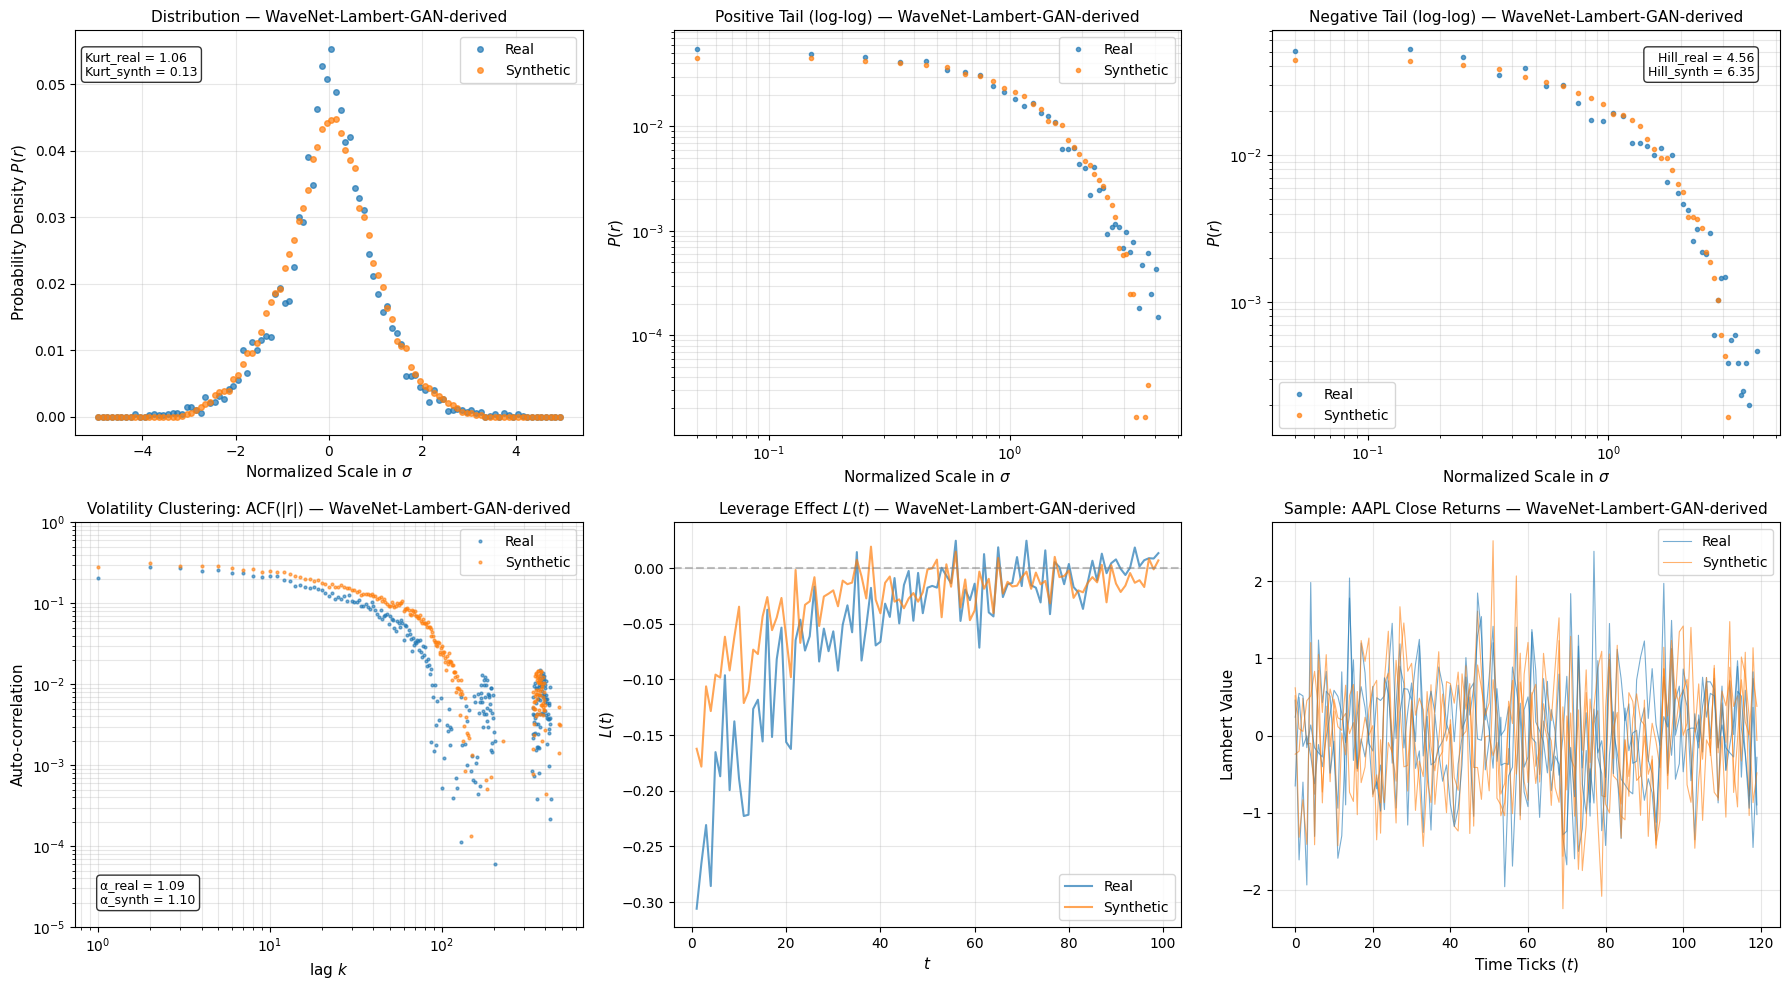

In [19]:
# --- Stylized Facts Plots (matching Wiese et al., 2020 Physica A figures) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution / PDF
axes[0, 0].plot(tail_dist['pdf_x'], tail_dist['pdf_real'],
                '.', markersize=8, alpha=0.7, label='Real')
axes[0, 0].plot(tail_dist['pdf_x'], tail_dist['pdf_synth'],
                '.', markersize=8, alpha=0.7, label='Synthetic')
axes[0, 0].set_title(f'Distribution — {MODEL_NAME}', fontsize=11)
axes[0, 0].set_xlabel(r'Normalized Scale in $\sigma$', fontsize=11)
axes[0, 0].set_ylabel(r'Probability Density $P(r)$', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0.02, 0.95,
                f"Kurt_real = {tail_dist['kurtosis_real']:.2f}\n"
                f"Kurt_synth = {tail_dist['kurtosis_synth']:.2f}",
                transform=axes[0, 0].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Positive tail (log-log)
pdf_x = tail_dist['pdf_x']
pdf_real = tail_dist['pdf_real']
pdf_synth = tail_dist['pdf_synth']

pos_mask = pdf_x > 0
pos_x = pdf_x[pos_mask]
pos_real = pdf_real[pos_mask]
pos_synth = pdf_synth[pos_mask]

axes[0, 1].plot(pos_x[pos_real > 0], pos_real[pos_real > 0],
                '.', markersize=6, alpha=0.7, label='Real')
axes[0, 1].plot(pos_x[pos_synth > 0], pos_synth[pos_synth > 0],
                '.', markersize=6, alpha=0.7, label='Synthetic')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title(f'Positive Tail (log-log) — {MODEL_NAME}', fontsize=11)
axes[0, 1].set_xlabel(r'Normalized Scale in $\sigma$', fontsize=11)
axes[0, 1].set_ylabel(r'$P(r)$', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, which='both')

# 3. Negative tail (log-log)
neg_mask = pdf_x < 0
neg_x = -pdf_x[neg_mask]
neg_real = pdf_real[neg_mask]
neg_synth = pdf_synth[neg_mask]

axes[0, 2].plot(neg_x[neg_real > 0], neg_real[neg_real > 0],
                '.', markersize=6, alpha=0.7, label='Real')
axes[0, 2].plot(neg_x[neg_synth > 0], neg_synth[neg_synth > 0],
                '.', markersize=6, alpha=0.7, label='Synthetic')
axes[0, 2].set_xscale('log')
axes[0, 2].set_yscale('log')
axes[0, 2].set_title(f'Negative Tail (log-log) — {MODEL_NAME}', fontsize=11)
axes[0, 2].set_xlabel(r'Normalized Scale in $\sigma$', fontsize=11)
axes[0, 2].set_ylabel(r'$P(r)$', fontsize=11)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, which='both')
axes[0, 2].text(0.95, 0.95,
                f"Hill_real = {tail_dist['hill_real']:.2f}\n"
                f"Hill_synth = {tail_dist['hill_synth']:.2f}",
                transform=axes[0, 2].transAxes, fontsize=9, verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Volatility Clustering ACF (log-log)
acf_lags = np.arange(1, len(vol_acf['acf_real']) + 1)
mask_r = vol_acf['acf_real'] > 0
mask_s = vol_acf['acf_synth'] > 0
axes[1, 0].plot(acf_lags[mask_r], vol_acf['acf_real'][mask_r],
                '.', markersize=4, alpha=0.6, label='Real')
axes[1, 0].plot(acf_lags[mask_s], vol_acf['acf_synth'][mask_s],
                '.', markersize=4, alpha=0.6, label='Synthetic')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_ylim(1e-5, 1.0)
axes[1, 0].set_title(f'Volatility Clustering: ACF(|r|) — {MODEL_NAME}', fontsize=11)
axes[1, 0].set_xlabel(r'lag $k$', fontsize=11)
axes[1, 0].set_ylabel('Auto-correlation', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')
axes[1, 0].text(0.05, 0.05,
                f"α_real = {vol_acf['decay_real']:.2f}\nα_synth = {vol_acf['decay_synth']:.2f}",
                transform=axes[1, 0].transAxes, fontsize=9, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 5. Leverage Effect (Bouchaud)
lags_b = lev_bouchaud['lags']
axes[1, 1].plot(lags_b, lev_bouchaud['leverage_real'], label='Real', alpha=0.7, linewidth=1.5)
axes[1, 1].plot(lags_b, lev_bouchaud['leverage_synth'], label='Synthetic', alpha=0.7, linewidth=1.5)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title(f'Leverage Effect $L(t)$ — {MODEL_NAME}', fontsize=11)
axes[1, 1].set_xlabel(r'$t$', fontsize=11)
axes[1, 1].set_ylabel(r'$L(t)$', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Sample time series — representative ticker close returns
t_idx = 0  # AAPL
col_idx = CLOSE_IDX[t_idx]
for i in range(3):
    axes[1, 2].plot(real_sequences[i, :, col_idx], alpha=0.6, color='C0', linewidth=0.8,
                    label='Real' if i == 0 else None)
    axes[1, 2].plot(synthetic_sequences[i, :, col_idx], alpha=0.6, color='C1', linewidth=0.8,
                    label='Synthetic' if i == 0 else None)
axes[1, 2].set_title(f'Sample: {ticker_list[t_idx]} Close Returns — {MODEL_NAME}', fontsize=11)
axes[1, 2].set_xlabel(r'Time Ticks ($t$)', fontsize=11)
axes[1, 2].set_ylabel('Lambert Value', fontsize=11)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary Dashboard

All scalar metrics in one table.

In [ ]:
ch = sorted(tail_results['mean_diff'].keys())[0]

print("=" * 65)
print(f"  {MODEL_NAME} — Evaluation Summary (Multi-Stock)")
print("=" * 65)
print(f"  {'Metric':<45} {'Value':>12}")
print("-" * 65)

# Distribution fidelity
print(f"  {'MMD (multi-scale RBF) ↓':<45} {mmd_results['mean']:>12.6f}")
print(f"  {'Wasserstein-1 ↓':<45} {dist_results['mean_wasserstein']:>12.6f}")
print(f"  {'KS statistic ↓':<45} {dist_results['mean_ks']:>12.4f}")
print(f"  {'KS p-value ↑':<45} {list(dist_results['ks_pvalue'].values())[0]:>12.4f}")
print(f"  {'JS divergence ↓':<45} {js_divergence:>12.6f}")

# Temporal dynamics
acf_ch = list(acf['returns'].keys())[0]
ret = acf['returns'][acf_ch]
sq = acf['squared'][acf_ch]
print(f"  {'ACF RMSE (returns) ↓':<45} {ret['rmse']:>12.6f}")
print(f"  {'ACF RMSE (squared returns) ↓':<45} {sq['rmse']:>12.6f}")

# Geometric
print(f"  {'Fréchet Distance (joint) ↓':<45} {fd_results['overall_fd']:>12.6f}")
print(f"  {'DTW distance (mean) ↓':<45} {dtw_score:>12.6f}")

# Tail metrics (first channel)
print(f"  {'Mean diff → 0':<45} {tail_results['mean_diff'][ch]:>12.6f}")
print(f"  {'Std ratio → 1.0':<45} {tail_results['std_ratio'][ch]:>12.4f}")
print(f"  {'Skewness diff → 0':<45} {tail_results['skew_diff'][ch]:>12.4f}")
print(f"  {'Kurtosis diff → 0':<45} {tail_results['kurtosis_diff'][ch]:>12.4f}")

# Discriminative (MLP)
print(f"  {'MLP Disc. score ↓':<45} {disc_results['score']:>12.4f}")
print(f"  {'MLP Disc. accuracy → 0.5':<45} {disc_results['accuracy']:>12.4f}")

# GRU classifier (fidelity)
print(f"  {'GRU Disc. score ↓':<45} {gru_disc_score:>12.4f}")
print(f"  {'GRU Disc. accuracy → 0.5':<45} {gru_test_acc:>12.4f}")
print(f"  {'GRU AUC → 0.5':<45} {gru_test_auc:>12.4f}")

# TSTR (usefulness)
print(f"  {'TSTR MAE (Synth→Real) ↓':<45} {tstr_mae:>12.6f}")
print(f"  {'TRTR MAE (Real→Real) ↓':<45} {trtr_mae:>12.6f}")
print(f"  {'TSTR/TRTR ratio → 1.0':<45} {tstr_mae / trtr_mae:>12.4f}")

# Entropy
_ech = list(entropy_results['shannon_real'].keys())[0]
print(f"  {'Shannon Entropy |Δ| (bits) ↓':<45} {entropy_results['shannon_diff'][_ech]:>12.4f}")
print(f"  {'Lempel-Ziv Complexity |Δ| ↓':<45} {entropy_results['lz_diff'][_ech]:>12.4f}")
print(f"  {'Plug-in Entropy w=2 |Δ| (bits) ↓':<45} {entropy_results['plugin2_diff'][_ech]:>12.4f}")

# QuantGAN metrics (1D close returns)
for key, val in dy_results.items():
    print(f"  {f'{key} (log-density div.) ↓':<45} {val:>12.4f}")

print(f"  {'--- ACF (Lambert close, windowed) ---':<45}")
print(f"  {'ACF(id) L2 ↓':<45} {qacf['acf_identity']:>12.4f}")
print(f"  {'ACF(x²) L2 ↓':<45} {qacf['acf_squared']:>12.4f}")
print(f"  {'ACF(|x|) L2 ↓':<45} {qacf['acf_absolute']:>12.4f}")

print(f"  {'--- ACF (close returns, contiguous) ---':<45}")
print(f"  {'ACF(id) L2 ↓':<45} {qacf_cont['acf_identity']:>12.4f}")
print(f"  {'ACF(x²) L2 ↓':<45} {qacf_cont['acf_squared']:>12.4f}")
print(f"  {'ACF(|x|) L2 ↓':<45} {qacf_cont['acf_absolute']:>12.4f}")

print(f"  {'Leverage Effect Score ↓':<45} {lev['leverage_score']:>12.4f}")

# Stylized Facts
print(f"  {'Bouchaud Leverage Score ↓':<45} {lev_bouchaud['leverage_score_bouchaud']:>12.4f}")
print(f"  {'Vol Clustering ACF Score ↓':<45} {vol_acf['acf_score']:>12.4f}")
print(f"  {'Vol Clustering Decay α (real)':<45} {vol_acf['decay_real']:>12.4f}")
print(f"  {'Vol Clustering Decay α (synth)':<45} {vol_acf['decay_synth']:>12.4f}")
print(f"  {'PDF RMSE ↓':<45} {tail_dist['pdf_rmse']:>12.6f}")
print(f"  {'Tail ratio 5% → 1.0':<45} {tail_dist['tail_ratio_5']:>12.4f}")
print(f"  {'Tail ratio 1% → 1.0':<45} {tail_dist['tail_ratio_1']:>12.4f}")
print(f"  {'Hill index α (real)':<45} {tail_dist['hill_real']:>12.4f}")
print(f"  {'Hill index α (synth)':<45} {tail_dist['hill_synth']:>12.4f}")

print("=" * 65)
print(f"\n  Scale: Lambert-transformed | Features: {N_FEATURES} ({N_TICKERS} tickers × 5 PV)")
print(f"  Samples: {n_eval} real, {n_eval} synthetic | Noise: half-real/half-noise")

  WaveNet-Lambert-GAN-derived — Evaluation Summary (Multi-Stock)
  Metric                                               Value
-----------------------------------------------------------------
  MMD (multi-scale RBF) ↓                           0.004031
  Wasserstein-1 ↓                                   0.087741
  KS statistic ↓                                      0.0712
  KS p-value ↑                                        0.0000
  JS divergence ↓                                   0.139926
  ACF RMSE (returns) ↓                              0.017268
  ACF RMSE (squared returns) ↓                      0.065885
  Fréchet Distance (joint) ↓                        4.799627
  DTW distance (mean) ↓                            70.590915
  Mean diff → 0                                     0.029144
  Std ratio → 1.0                                     1.0004
  Skewness diff → 0                                   0.0429
  Kurtosis diff → 0                                   0.0589
  MLP Disc. sco

## 7. Evaluation Logging & Comparison

Append all metrics to a CSV file for tracking progress across model iterations.
Run this cell after each evaluation to build a comparison dataset.

In [21]:
import datetime
import os

# ============================================================
# Build metrics dictionary for this evaluation run
# ============================================================
acf_ch = list(acf['returns'].keys())[0]
ret = acf['returns'][acf_ch]
sq = acf['squared'][acf_ch]
_ech = list(entropy_results['shannon_real'].keys())[0]
ch = sorted(tail_results['mean_diff'].keys())[0]

eval_record = {
    # Run metadata
    'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_name': MODEL_NAME,
    'generator_path': os.path.basename(MODEL_DIR),
    'preprocessing': 'lambert_multistock',
    'noise_type': 'half_real_half_noise',
    'seq_len': SEQ_LEN,
    'feature_dim': N_FEATURES,
    'n_tickers': N_TICKERS,
    'n_samples': n_eval,

    # Distribution fidelity
    'mmd': mmd_results['mean'],
    'wasserstein_1': dist_results['mean_wasserstein'],
    'ks_statistic': dist_results['mean_ks'],
    'ks_pvalue': list(dist_results['ks_pvalue'].values())[0],
    'js_divergence': js_divergence,

    # Temporal dynamics
    'acf_rmse_returns': ret['rmse'],
    'acf_rmse_squared': sq['rmse'],

    # Geometric
    'frechet_distance': fd_results['overall_fd'],
    'dtw_distance': dtw_score,

    # Tail metrics (first channel)
    'mean_diff': tail_results['mean_diff'][ch],
    'std_ratio': tail_results['std_ratio'][ch],
    'skew_diff': tail_results['skew_diff'][ch],
    'kurtosis_diff': tail_results['kurtosis_diff'][ch],

    # Discriminative
    'mlp_disc_score': disc_results['score'],
    'mlp_disc_accuracy': disc_results['accuracy'],
    'gru_disc_score': gru_disc_score,
    'gru_disc_accuracy': gru_test_acc,
    'gru_auc': gru_test_auc,

    # TSTR
    'tstr_mae': tstr_mae,
    'trtr_mae': trtr_mae,
    'tstr_trtr_ratio': tstr_mae / trtr_mae,

    # Entropy
    'shannon_entropy_diff': entropy_results['shannon_diff'][_ech],
    'lz_complexity_diff': entropy_results['lz_diff'][_ech],
    'plugin_entropy_diff': entropy_results['plugin2_diff'][_ech],

    # QuantGAN metrics — DY (1D close returns)
    'dy_lag1': dy_results.get('lag_1', np.nan),
    'dy_lag5': dy_results.get('lag_5', np.nan),
    'dy_lag20': dy_results.get('lag_20', np.nan),

    # ACF — Lambert close windowed
    'acf_identity': qacf['acf_identity'],
    'acf_squared': qacf['acf_squared'],
    'acf_absolute': qacf['acf_absolute'],

    # ACF — Close returns contiguous
    'acf_cont_identity_l2': qacf_cont['acf_identity'],
    'acf_cont_squared_l2': qacf_cont['acf_squared'],
    'acf_cont_absolute_l2': qacf_cont['acf_absolute'],
    'acf_cont_identity_mse': qacf_cont['acf_identity_mse'],
    'acf_cont_squared_mse': qacf_cont['acf_squared_mse'],
    'acf_cont_absolute_mse': qacf_cont['acf_absolute_mse'],

    'leverage_score': lev['leverage_score'],

    # Stylized facts
    'bouchaud_leverage_score': lev_bouchaud['leverage_score_bouchaud'],
    'vol_clustering_acf_score': vol_acf['acf_score'],
    'vol_clustering_decay_real': vol_acf['decay_real'],
    'vol_clustering_decay_synth': vol_acf['decay_synth'],
    'pdf_rmse': tail_dist['pdf_rmse'],
    'tail_ratio_5pct': tail_dist['tail_ratio_5'],
    'tail_ratio_1pct': tail_dist['tail_ratio_1'],
    'hill_index_real': tail_dist['hill_real'],
    'hill_index_synth': tail_dist['hill_synth'],
}

# ============================================================
# Append to CSV
# ============================================================
EVAL_LOG_PATH = '../data/evaluation_log.csv'

eval_df = pd.DataFrame([eval_record])

if os.path.exists(EVAL_LOG_PATH):
    existing_df = pd.read_csv(EVAL_LOG_PATH)
    existing_df.columns = existing_df.columns.str.strip()
    combined_df = pd.concat([existing_df, eval_df], ignore_index=True)
    combined_df.to_csv(EVAL_LOG_PATH, index=False)
    print(f"✓ Appended evaluation to {EVAL_LOG_PATH}")
    if len(eval_df.columns) > len(existing_df.columns):
        new_cols = set(eval_df.columns) - set(existing_df.columns)
        print(f"  ⚠ Added {len(new_cols)} new column(s): {', '.join(sorted(new_cols))}")
else:
    os.makedirs(os.path.dirname(EVAL_LOG_PATH), exist_ok=True)
    eval_df.to_csv(EVAL_LOG_PATH, mode='w', header=True, index=False)
    print(f"✓ Created {EVAL_LOG_PATH} with first evaluation")

✓ Appended evaluation to ../data/evaluation_log.csv


Loaded 7 evaluation(s) from ../data/evaluation_log.csv



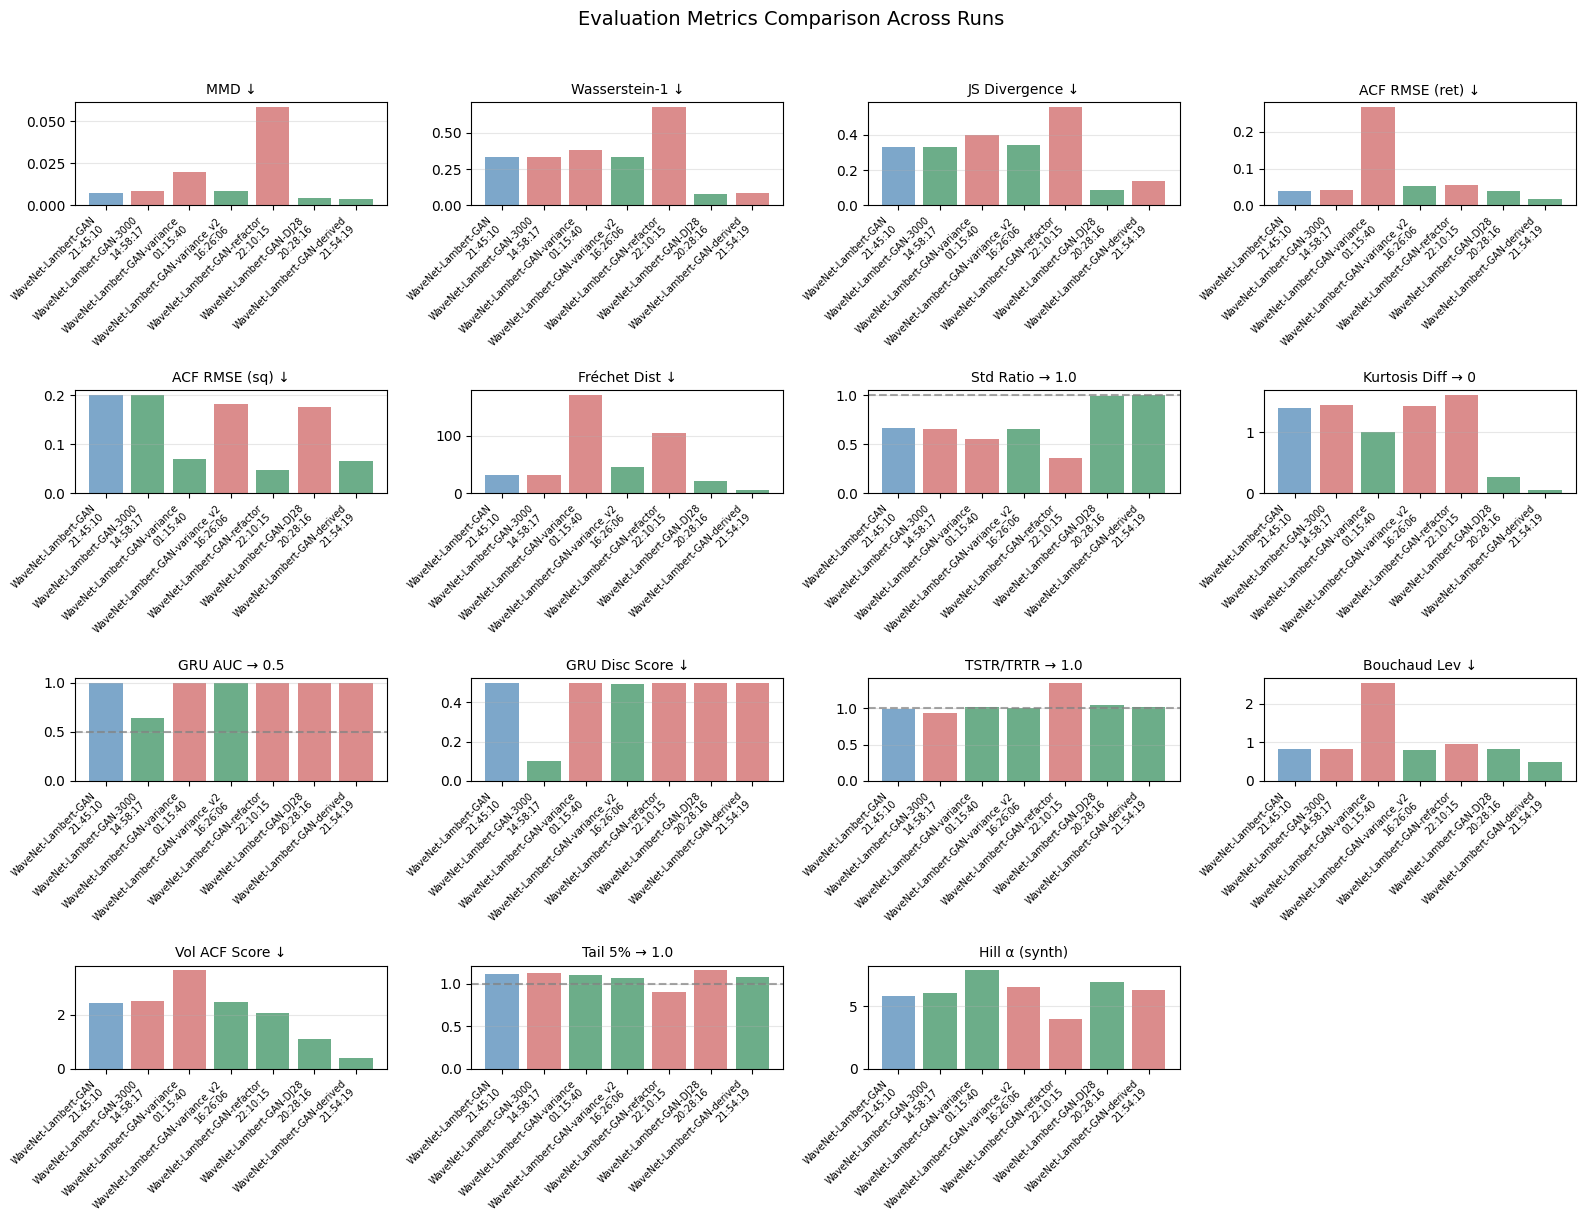


Recent Evaluations (last 5):
          timestamp                      model_name      mmd  gru_auc  std_ratio  kurtosis_diff  tstr_trtr_ratio
2026-04-18 01:15:40    WaveNet-Lambert-GAN-variance 0.019610   1.0000   0.552612       1.012278         1.021071
2026-04-18 16:26:06 WaveNet-Lambert-GAN-variance_v2 0.008502   0.9944   0.649182       1.433559         1.006822
2026-04-19 22:10:15    WaveNet-Lambert-GAN-refactor 0.058303   1.0000   0.356673       1.611249         1.354231
2026-04-20 20:28:16        WaveNet-Lambert-GAN-DJ28 0.004303   1.0000   0.992223       0.269014         1.043278
2026-04-20 21:54:19     WaveNet-Lambert-GAN-derived 0.004031   1.0000   1.000356       0.058857         1.017918


In [22]:
# ============================================================
# Load and visualize evaluation history
# ============================================================
if not os.path.exists(EVAL_LOG_PATH):
    print("No evaluation log found. Run the logging cell first.")
else:
    log_df = pd.read_csv(EVAL_LOG_PATH)
    print(f"Loaded {len(log_df)} evaluation(s) from {EVAL_LOG_PATH}\n")
    
    # Key metrics to compare (lower is better unless noted)
    metrics_config = {
        # Distribution fidelity
        'mmd': {'label': 'MMD ↓', 'lower_better': True},
        'wasserstein_1': {'label': 'Wasserstein-1 ↓', 'lower_better': True},
        'js_divergence': {'label': 'JS Divergence ↓', 'lower_better': True},
        
        # Temporal
        'acf_rmse_returns': {'label': 'ACF RMSE (ret) ↓', 'lower_better': True},
        'acf_rmse_squared': {'label': 'ACF RMSE (sq) ↓', 'lower_better': True},
        
        # Geometric
        'frechet_distance': {'label': 'Fréchet Dist ↓', 'lower_better': True},
        
        # Tail
        'std_ratio': {'label': 'Std Ratio → 1.0', 'lower_better': False, 'target': 1.0},
        'kurtosis_diff': {'label': 'Kurtosis Diff → 0', 'lower_better': True},
        
        # Discriminative
        'gru_auc': {'label': 'GRU AUC → 0.5', 'lower_better': False, 'target': 0.5},
        'gru_disc_score': {'label': 'GRU Disc Score ↓', 'lower_better': True},
        
        # TSTR
        'tstr_trtr_ratio': {'label': 'TSTR/TRTR → 1.0', 'lower_better': False, 'target': 1.0},
        
        # Stylized facts
        'bouchaud_leverage_score': {'label': 'Bouchaud Lev ↓', 'lower_better': True},
        'vol_clustering_acf_score': {'label': 'Vol ACF Score ↓', 'lower_better': True},
        'tail_ratio_5pct': {'label': 'Tail 5% → 1.0', 'lower_better': False, 'target': 1.0},
        'hill_index_synth': {'label': 'Hill α (synth)', 'lower_better': False},
    }
    
    # Select metrics that exist in the log
    available_metrics = [m for m in metrics_config if m in log_df.columns]
    
    if len(log_df) >= 2:
        # Plot comparison across runs
        n_metrics = len(available_metrics)
        n_cols = 4
        n_rows = (n_metrics + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
        axes = axes.flatten()
        
        # X-axis: model names with timestamps (truncated, NaN-safe)
        x_labels = [f"{row['model_name']}\n{str(row['timestamp'])[-8:]}"
                    if pd.notna(row['timestamp'])
                    else str(row['model_name'])
                    for _, row in log_df.iterrows()]
        x = np.arange(len(log_df))
        
        for i, metric in enumerate(available_metrics):
            ax = axes[i]
            cfg = metrics_config[metric]
            values = log_df[metric].values
            
            # Color bars: green if improving, red if worsening
            colors = []
            for j, val in enumerate(values):
                if j == 0:
                    colors.append('steelblue')
                else:
                    prev = values[j - 1]
                    if 'target' in cfg:
                        # Closer to target is better
                        improved = abs(val - cfg['target']) < abs(prev - cfg['target'])
                    elif cfg['lower_better']:
                        improved = val < prev
                    else:
                        improved = val > prev
                    colors.append('seagreen' if improved else 'indianred')
            
            ax.bar(x, values, color=colors, alpha=0.7)
            ax.set_title(cfg['label'], fontsize=10)
            ax.set_xticks(x)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=7)
            
            # Add target line if applicable
            if 'target' in cfg:
                ax.axhline(cfg['target'], color='gray', linestyle='--', alpha=0.7)
            
            ax.grid(True, alpha=0.3, axis='y')
        
        # Hide unused axes
        for j in range(len(available_metrics), len(axes)):
            axes[j].set_visible(False)
        
        plt.suptitle('Evaluation Metrics Comparison Across Runs', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Summary table of recent runs
        print("\n" + "=" * 80)
        print("Recent Evaluations (last 5):")
        print("=" * 80)
        display_cols = ['timestamp', 'model_name', 'mmd', 'gru_auc', 'std_ratio', 
                        'kurtosis_diff', 'tstr_trtr_ratio']
        display_cols = [c for c in display_cols if c in log_df.columns]
        print(log_df[display_cols].tail(5).to_string(index=False))
    else:
        print("Only 1 evaluation in log. Run more evaluations to compare.")
        print(log_df.T)